# Data Quality Validation & Profiling

This notebook covers 8 dimensions: Completeness, Uniqueness, Consistency, Accuracy, Outlier Detection (Z-score, IQR, Isolation Forest), Distribution Profiling, Relationships Profiling, and Report Generation.

## 1. Environment Setup and Data Loading
Import essential libraries and load the dataset into a DataFrame.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
# Adjust the path if necessary
file_path = '../OSM/all_properties_with_osm.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Data loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    print("File not found. Please verify the path.")
    # Creating a dummy dataframe for demonstration if file not found
    df = pd.DataFrame({'price': np.random.normal(100, 20, 100), 'area': np.random.normal(50, 10, 100), 'id': range(100)})

# Dictionary to hold report summaries
report_summary = {}

Data loaded successfully! Shape: (71405, 66)


## 2. Accuracy Validation
Verify data types against expected schemas and check numerical values against acceptable domain limits (e.g., price > 0).

In [2]:
print("--- Accuracy Validation ---")
accuracy_issues = 0

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    # Assuming physical quantities (like area, price, etc.) shouldn't be negative generally
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"Warning: Column '{col}' contains {negative_count} negative values.")
        accuracy_issues += negative_count

if accuracy_issues == 0:
    print("Basic numeric boundaries look accurate (no negative values where positive expected).")

report_summary['Accuracy'] = f"{accuracy_issues} basic numerical boundary violations found."
print(f"Result: {report_summary['Accuracy']}")

--- Accuracy Validation ---
Basic numeric boundaries look accurate (no negative values where positive expected).
Result: 0 basic numerical boundary violations found.


## 3. Consistency Validation\n
Apply logical checks across columns. (Add custom specific logical checks here).

In [9]:
print("--- Consistency Validation ---")
consistency_errors = []
total_records = len(df)

# 1. Capitalization Consistency Checks (e.g. "cairo" vs "Cairo")
categorical_cols = ['city', 'town', 'district', 'property_type', 'listing_type']
for col in categorical_cols:
    if col in df.columns:
        # Check if converting to lowercase reduces the number of unique values
        lower_vals = df[col].dropna().astype(str).str.lower()
        original_unique = df[col].nunique()
        lower_unique = lower_vals.nunique()
        if original_unique > lower_unique:
            inconsistent_caps = original_unique - lower_unique
            print(f"[{col}] Found {inconsistent_caps} capitalization discrepancies.")
            consistency_errors.append(f"{col} capitalization mismatch")

# 2. Units Uniformity Checks (e.g. mixing meters and feet, or currencies)
units_cols = ['area_unit', 'price_currency']
for col in units_cols:
    if col in df.columns:
        unique_units = df[col].dropna().unique()
        if len(unique_units) > 1:
            print(f"[{col}] Inconsistent units found in the same column: {unique_units}")
            consistency_errors.append(f"Mixed {col}")

# 3. Logical/Relational Consistency 
# (e.g. area vs bedrooms, reasonable values)
if 'area_value' in df.columns and 'bedrooms' in df.columns:
    # Check for properties with 3+ bedrooms but exceptionally small areas (< 20 units)
    bad_area_beds = df[(pd.to_numeric(df['bedrooms'], errors='coerce') > 2) & 
                       (pd.to_numeric(df['area_value'], errors='coerce') < 25)]
    if len(bad_area_beds) > 0:
        print(f"[Logic Check] Found {len(bad_area_beds)} records with illogical area-to-bedroom ratios.")
        consistency_errors.append("Illogical area vs bedrooms")

# 4. Mixed Data Types Consistency (Checking for string values in expected numeric columns)
expected_numeric_cols = ['bedrooms', 'bathrooms', 'price', 'area_value', 'parking_spaces', 'floor_level']
for col in expected_numeric_cols:
    if col in df.columns:
        # Find values that cannot be converted to numeric
        non_numeric_mask = pd.to_numeric(df[col], errors='coerce').isna()
        # Keep non-numeric values that are not actually just empty/NaN themselves
        non_numeric_vals = df.loc[non_numeric_mask & df[col].notna(), col].unique()
        
        if len(non_numeric_vals) > 0:
            print(f"[{col.capitalize()} Consistency] Found non-numeric values (e.g., strings) in {col}: {non_numeric_vals}")
            consistency_errors.append(f"Mixed types in {col}")

# 5. Date Format & Time Consistency (e.g. listed_date vs scraped_at)
if 'listed_date' in df.columns and 'scraped_at' in df.columns:
    # Force both dates to UTC to avoid tz-naive vs tz-aware comparison errors
    listed_dt = pd.to_datetime(df['listed_date'], errors='coerce', utc=True)
    scraped_dt = pd.to_datetime(df['scraped_at'], errors='coerce', utc=True)
    
    # Check for unparseable "messy" date formats
    unparsed_listed = df['listed_date'].notna() & listed_dt.isna()
    if unparsed_listed.sum() > 0:
        print(f"[Date Formatting] Found {unparsed_listed.sum()} badly formatted listed_date values (e.g. DD-MM-YYYY vs MM/DD/YYYY).")
        consistency_errors.append("Inconsistent listed_date formats")
    
    # Logical check: listing date shouldn't be after scraping date
    invalid_dates = (listed_dt > scraped_dt).sum()
    if invalid_dates > 0:
        print(f"[Date Consistency] Found {invalid_dates} records where a property was listed AFTER it was scraped (MM/DD/YYYY vs DD/MM/YYYY swap issues).")
        consistency_errors.append("Listed date > scraped date")

report_summary['Consistency'] = f"{len(consistency_errors)} types of consistency issues found."
print(f"\nTotal structural consistency issues flagged: {len(consistency_errors)}")
print(f"Result: {report_summary['Consistency']}")

--- Consistency Validation ---
[district] Found 7 capitalization discrepancies.
[area_unit] Inconsistent units found in the same column: <StringArray>
['sqm', 'SQM']
Length: 2, dtype: str
[Logic Check] Found 1074 records with illogical area-to-bedroom ratios.
[Bedrooms Consistency] Found non-numeric values (e.g., strings) in bedrooms: ['studio' '7+']
[Date Formatting] Found 33627 badly formatted listed_date values (e.g. DD-MM-YYYY vs MM/DD/YYYY).

Total structural consistency issues flagged: 5
Result: 5 types of consistency issues found.


## 4. Completeness Analysis\n
Calculate the percentage of missing values per column and identify rows with significant data gaps.

In [ ]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
completeness_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
completeness_df = completeness_df[completeness_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("--- Completeness Analysis ---")
print(completeness_df)

report_summary['Completeness'] = f"{len(completeness_df)} columns have missing values."
print(f"Result: {report_summary['Completeness']}")

--- Completeness Analysis ---
                   Missing Values  Percentage (%)
rera                        71405      100.000000
video_url                   71203       99.717107
agent_languages             62639       87.723549
payment_plan                52022       72.854842
broker_email                33821       47.365030
amenities                   33657       47.135355
agent_email                 33627       47.093341
is_exclusive                33627       47.093341
description                 33627       47.093341
price_period                33627       47.093341
subdistrict                 29158       40.834675
completion_status           18566       26.000980
furnished                   13358       18.707373
agent_is_verified            6188        8.666060
district                     5258        7.363630
contact_whatsapp              519        0.726840
broker_phone                  224        0.313704
bedrooms                       32        0.044815
contact_phone       

## 5. Uniqueness Analysis\n
Detect and quantify exact duplicate rows and compute the cardinality of categorical features.

In [ ]:
duplicates_count = df.duplicated().sum()
duplicates_percent = (duplicates_count / len(df)) * 100

print("--- Uniqueness Analysis ---")
print(f"Exact duplicate rows: {duplicates_count} ({duplicates_percent:.2f}%)")

# Cardinality of categorical features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
cardinality = {col: df[col].nunique() for col in categorical_cols}
print("\nCardinality of Categorical Columns:")
for col, count in cardinality.items():
    print(f"{col}: {count} unique values")

report_summary['Uniqueness'] = f"{duplicates_count} duplicate rows found."
print(f"Result: {report_summary['Uniqueness']}")

--- Uniqueness Analysis ---
Exact duplicate rows: 0 (0.00%)

Cardinality of Categorical Columns:
listing_id: 71405 unique values
internal_id: 71269 unique values
category: 3 unique values
listing_type: 15 unique values
detail_url: 71405 unique values
property_type: 33 unique values
offering_type: 3 unique values
completion_status: 5 unique values
title: 64868 unique values
price_period: 2 unique values
price_currency: 1 unique values
location_full: 3354 unique values
city: 22 unique values
town: 161 unique values
district: 1250 unique values
subdistrict: 1470 unique values
bedrooms: 24 unique values
bathroom: 33 unique values
area_unit: 2 unique values
furnished: 5 unique values
listing_level: 5 unique values
is_exclusive: 1 unique values
listed_date: 67957 unique values
video_url: 154 unique values
reference: 71002 unique values
description: 34733 unique values
amenities: 17438 unique values
payment_plan: 3 unique values
agent_id: 6038 unique values
agent_name: 4796 unique values
agen

## 6. Outlier Detection using Z-Score
Flag records that fall outside of a specified standard deviation.

In [ ]:
print("--- Outlier Detection: Z-Score ---")
z_threshold = 3.0
z_outliers = pd.DataFrame()

for col in numeric_cols:
    # Ignore id-like columns and NaN values
    if df[col].nunique() > 10 and not col.lower().endswith('id'):
        col_data = df[col].dropna()
        z_scores = np.abs(stats.zscore(col_data))
        outliers = col_data[z_scores > z_threshold]
        print(f"{col}: {len(outliers)} outliers detected (Z-score > {z_threshold})")
        
report_summary['Z-Score Outliers'] = "Z-score evaluated for numeric columns."
print(f"Result: {report_summary['Z-Score Outliers']}")

--- Outlier Detection: Z-Score ---
price_egp: 513 outliers detected (Z-score > 3.0)
lat: 3301 outliers detected (Z-score > 3.0)
lon: 2308 outliers detected (Z-score > 3.0)
area_value: 161 outliers detected (Z-score > 3.0)
images_count: 1574 outliers detected (Z-score > 3.0)
broker_phone: 0 outliers detected (Z-score > 3.0)
contact_phone: 1 outliers detected (Z-score > 3.0)
contact_whatsapp: 0 outliers detected (Z-score > 3.0)
dist_nearest_school_km: 2101 outliers detected (Z-score > 3.0)
school_count_within_1.5km: 1565 outliers detected (Z-score > 3.0)
dist_nearest_hospital_km: 3249 outliers detected (Z-score > 3.0)
hospital_count_within_1.5km: 1962 outliers detected (Z-score > 3.0)
dist_nearest_supermarket_km: 2008 outliers detected (Z-score > 3.0)
supermarket_count_within_1.5km: 1508 outliers detected (Z-score > 3.0)
dist_nearest_mall_km: 2636 outliers detected (Z-score > 3.0)
dist_nearest_transit_station_km: 1319 outliers detected (Z-score > 3.0)
transit_station_count_within_1.5km: 

## 7. Outlier Detection using IQR
Compute the Interquartile Range and identify outliers beyond the 1.5 * IQR bounds.

In [ ]:
print("--- Outlier Detection: IQR ---")
iqr_outliers_summary = {}

for col in numeric_cols:
    if df[col].nunique() > 10 and not col.lower().endswith('id'):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"{col}: {len(outliers)} outliers detected using IQR method")
        iqr_outliers_summary[col] = len(outliers)
        
report_summary['IQR Outliers'] = "IQR calculated for numeric columns."
print(f"Result: {report_summary['IQR Outliers']}")

--- Outlier Detection: IQR ---
price_egp: 4107 outliers detected using IQR method
lat: 12559 outliers detected using IQR method
lon: 10477 outliers detected using IQR method
area_value: 4969 outliers detected using IQR method
images_count: 8948 outliers detected using IQR method
broker_phone: 10213 outliers detected using IQR method
contact_phone: 2243 outliers detected using IQR method
contact_whatsapp: 0 outliers detected using IQR method
dist_nearest_school_km: 9616 outliers detected using IQR method
school_count_within_1.5km: 15706 outliers detected using IQR method
dist_nearest_hospital_km: 8926 outliers detected using IQR method
hospital_count_within_1.5km: 15928 outliers detected using IQR method
dist_nearest_supermarket_km: 8176 outliers detected using IQR method
supermarket_count_within_1.5km: 12521 outliers detected using IQR method
dist_nearest_mall_km: 7849 outliers detected using IQR method
dist_nearest_transit_station_km: 1473 outliers detected using IQR method
transit_st

## 8. Outlier Detection using Isolation Forest
Train an Isolation Forest model from scikit-learn to detect multivariate anomalies.

In [ ]:
print("--- Outlier Detection: Isolation Forest ---")

# Use only numeric columns, drop NaNs for simplicity
iso_df = df[numeric_cols].dropna()
if len(iso_df) > 0:
    clf = IsolationForest(contamination=0.05, random_state=42)
    preds = clf.fit_predict(iso_df)
    
    multivariate_outliers = (preds == -1).sum()
    print(f"Detected {multivariate_outliers} multivariate outliers out of {len(iso_df)} complete num-records.")
    report_summary['Isolation Forest'] = f"{multivariate_outliers} anomalies detected."
else:
    print("Not enough numeric data without NaNs to run Isolation Forest.")
    report_summary['Isolation Forest'] = "Insufficient data."
print(f"Result: {report_summary['Isolation Forest']}")

--- Outlier Detection: Isolation Forest ---
Not enough numeric data without NaNs to run Isolation Forest.


## 9. Distribution Profiling
Generate statistical summaries, histograms, and density plots to analyze the univariate distribution.

--- Distribution Profiling ---


,price_egp,lat,lon,area_value,images_count,rera,broker_id,broker_phone,contact_phone,contact_whatsapp,...,dist_nearest_hospital_km,hospital_count_within_1.5km,dist_nearest_supermarket_km,supermarket_count_within_1.5km,dist_nearest_mall_km,mall_count_within_1.5km,dist_nearest_transit_station_km,transit_station_count_within_1.5km,dist_nearest_cafe_restaurant_km,cafe_restaurant_count_within_1.5km
count,7.140500e+04,71405.000000,71405.000000,71405.000000,71405.000000,0.0,71405.000000,7.118100e+04,7.137500e+04,7.088600e+04,...,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000,71405.000000
mean,1.138198e+07,29.981210,31.255680,266.666648,12.121210,NaN,8399.092613,1.749965e+11,1.687795e+14,1.270482e+11,...,9.906414,0.733632,4.723948,1.909586,16.793087,0.132778,5.494010,0.266424,3.425623,4.802339
std,2.726821e+07,0.701307,1.015430,1467.448118,4.743487,NaN,10970.987493,6.738524e+10,4.503757e+16,8.895113e+10,...,18.903603,2.464667,6.935079,5.188787,40.270902,0.470848,4.036463,1.145838,5.978542,14.085780
min,1.300000e+03,25.069366,25.476135,1.000000,1.000000,NaN,3.000000,1.000009e+09,2.010022e+10,2.050008e+08,...,0.010000,0.000000,0.009000,0.000000,0.066000,0.000000,0.005000,0.000000,0.002000,0.000000
25%,2.431660e+05,29.995922,30.998248,130.000000,10.000000,NaN,2290.000000,2.010120e+11,2.010338e+11,2.022126e+10,...,1.691000,0.000000,1.031000,0.000000,2.449000,0.000000,3.116000,0.000000,0.791000,0.000000
50%,6.500000e+06,30.028351,31.483500,173.000000,11.000000,NaN,4965.000000,2.010708e+11,2.011010e+11,2.010800e+11,...,3.893000,0.000000,2.365000,0.000000,4.383000,0.000000,4.865000,0.000000,1.565000,0.000000
75%,1.360000e+07,30.071285,31.572048,244.000000,13.000000,NaN,14109.000000,2.011411e+11,2.011493e+11,2.011036e+11,...,7.118000,0.000000,4.723000,1.000000,7.248000,0.000000,7.426000,0.000000,3.225000,2.000000
max,1.885000e+09,31.497467,34.896572,134400.000000,76.000000,NaN,179957.000000,2.015599e+11,1.203228e+19,2.015600e+11,...,284.592000,35.000000,305.035000,58.000000,489.463000,7.000000,90.306000,22.000000,77.675000,183.000000


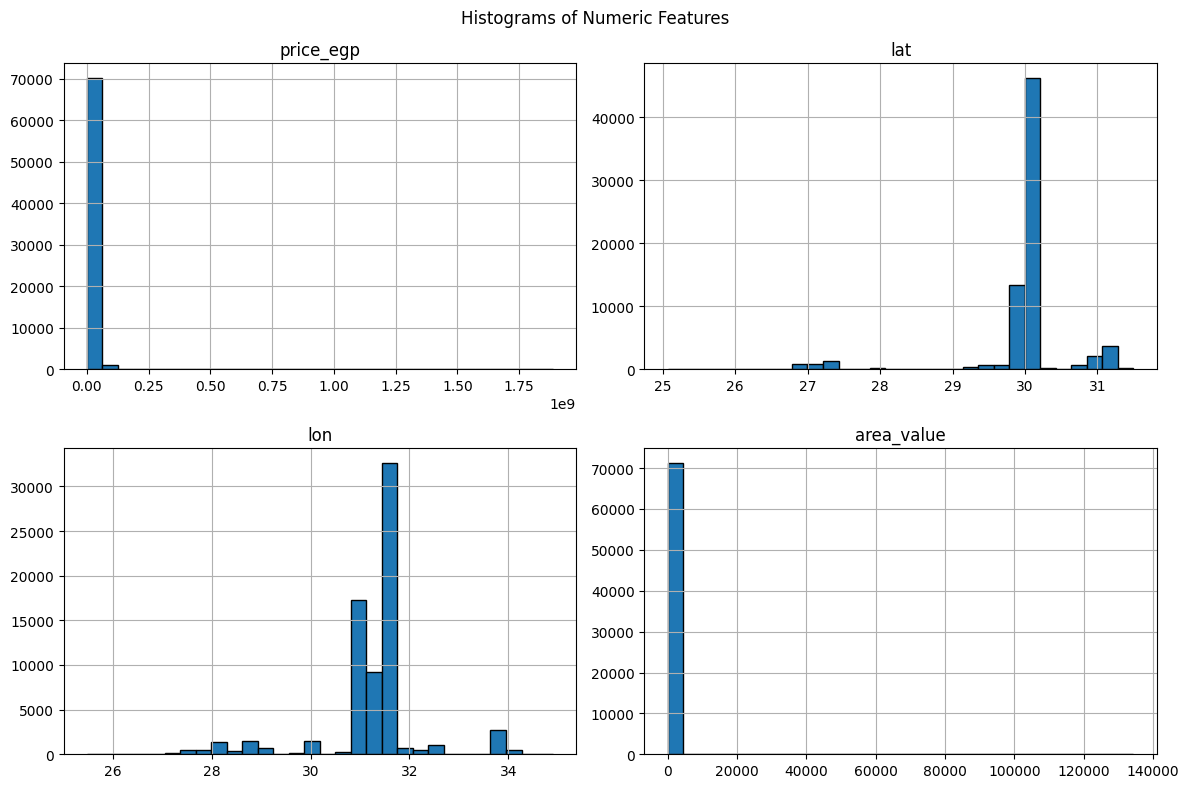

In [ ]:
print("--- Distribution Profiling ---")
display(df.describe())

# Select a few numeric columns to plot histograms
cols_to_plot = numeric_cols[:4]  # taking up to 4 columns to keep plot clean
df[cols_to_plot].hist(bins=30, figsize=(12, 8), edgecolor='black')
plt.suptitle('Histograms of Numeric Features')
plt.tight_layout()
plt.show()

report_summary['Distribution'] = "Summary statistics and histograms generated."
print(f"Result: {report_summary['Distribution']}")

## 10. Relationships Profiling
Compute correlation matrices and generate pair plots to identify relationships.

--- Relationships Profiling ---


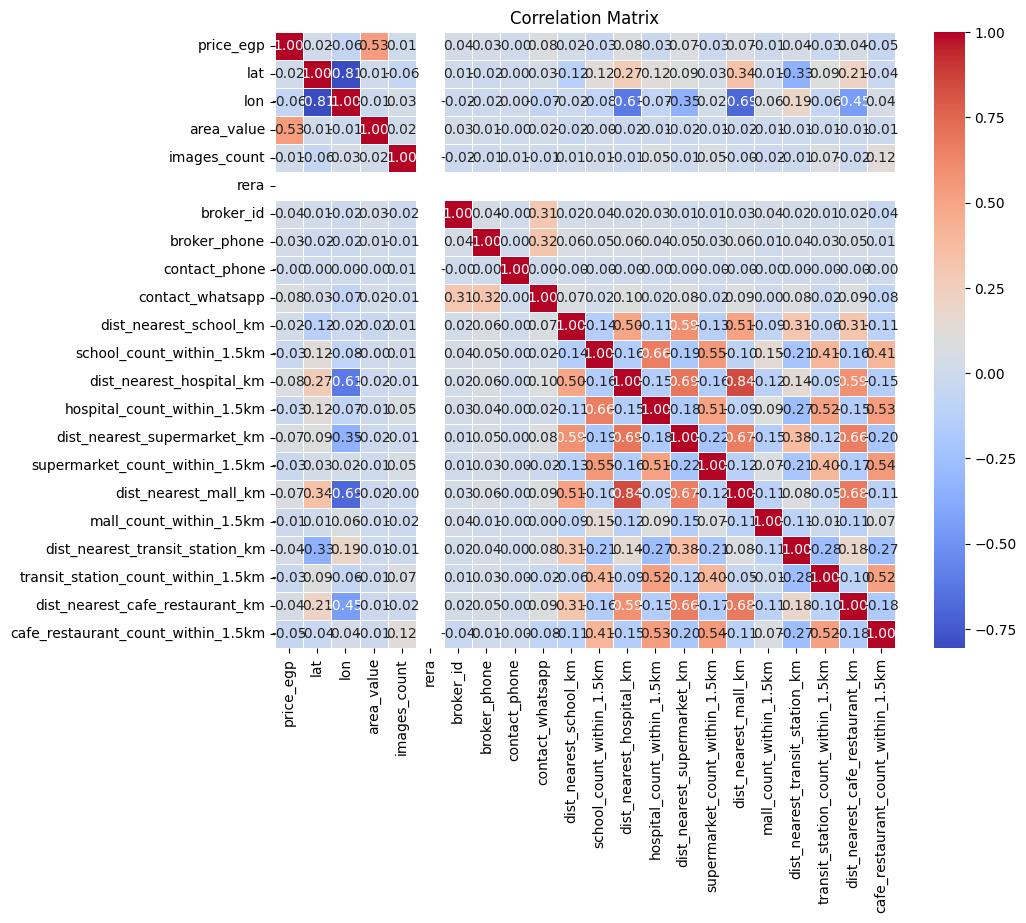

In [ ]:
print("--- Relationships Profiling ---")

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.show()
    
    report_summary['Relationships'] = "Correlation matrix evaluated."
else:
    print("Not enough numeric columns for relationship profiling.")
    report_summary['Relationships'] = "Insufficient numeric columns."
print(f"Result: {report_summary['Relationships']}")

## 11. Generate Data Quality Report
Aggregate the metrics and findings into a structured summary DataFrame.

In [13]:
print("====================================")
print("       DATA QUALITY REPORT          ")
print("====================================")

report_df = pd.DataFrame(list(report_summary.items()), columns=['Dimension', 'Findings / Summary'])
display(report_df)

# Optionally, export to CSV
# report_df.to_csv('data_quality_report.csv', index=False)
print("Report generation complete.")

       DATA QUALITY REPORT          


,Dimension,Findings / Summary
0,Accuracy,0 basic numerical boundary violations found.
1,Consistency,4 types of consistency issues found.
2,Completeness,21 columns have missing values.
3,Uniqueness,0 duplicate rows found.
4,Z-Score Outliers,Z-score evaluated for numeric columns.
5,IQR Outliers,IQR calculated for numeric columns.
6,Isolation Forest,Insufficient data.
7,Distribution,Summary statistics and histograms generated.
8,Relationships,Correlation matrix evaluated.


Report generation complete.
